In [1]:
import pandas as pd

df=pd.read_csv('../data/bank-marketing-cleaned.csv')

In [3]:
df.drop(['duration'],axis=1,inplace=True)

In [4]:
df.describe()

,age,balance,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,63.000000,871.000000,275.000000,1.000000


## Statistical Analysis

In [5]:
from scipy.stats import chi2_contingency

cat_cols = ['job','marital','education','default','housing','loan','contact']

for col in cat_cols:
    table = pd.crosstab(df[col], df['y'])
    chi2, p, _, _ = chi2_contingency(table)
    
    print(f"{col}: p-value = {p}")

job: p-value = 5.575427995540736e-172
marital: p-value = 2.1450999986791792e-43
education: p-value = 1.6266562124072994e-51
default: p-value = 2.4538606753508344e-06
housing: p-value = 2.918797605076633e-192
loan: p-value = 1.665061163492756e-47
contact: p-value = 1.251738325340495e-225


In [6]:
from scipy.stats import ttest_ind

num_cols = ['age','balance','campaign','pdays','previous']

for col in num_cols:
    group1 = df[df['y']==1][col]
    group0 = df[df['y']==0][col]
    
    stat, p = ttest_ind(group1, group0)
    
    print(f"{col}: p-value = {p}")

age: p-value = 8.825643691922399e-08
balance: p-value = 2.5211136918751785e-29
campaign: p-value = 1.0123473642095526e-54
pdays: p-value = 3.790553319478042e-108
previous: p-value = 7.801830349805128e-88


In [18]:
from scipy.stats import mannwhitneyu
for col in num_cols:
    group1 = df[df['y']==1][col]
    group0 = df[df['y']==0][col]
    
    stat, p = mannwhitneyu(group1, group0)
    
    print(f"{col}: p-value = {p}")

age: p-value = 0.06281791018697587
balance: p-value = 6.593845808689515e-101
campaign: p-value = 1.9484904873905108e-71
pdays: p-value = 2.4841176503776935e-235
previous: p-value = 3.491824260414992e-283


In [17]:
import numpy as np
import statsmodels.api as sm

X=df[['age','balance','campaign','pdays','previous']]
y = df['y']

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.350525
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45205
Method:                           MLE   Df Model:                            5
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                 0.02868
Time:                        14:33:42   Log-Likelihood:                -15848.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                4.764e-200
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1997      0.061    -35.768      0.000      -2.320      -2.079
age            0.0068      0.

In [27]:
for i in df[num_cols]:
    print(i,(np.mean(df[i])-np.mean(df['y']))/np.sqrt((np.var(df[i])+np.var(df['y']))/2))

age 5.433902308116794
balance 0.6326921609528097
campaign 1.2018245044916107
pdays 0.5661032332384122
previous 0.2817435937823455


<Axes: >

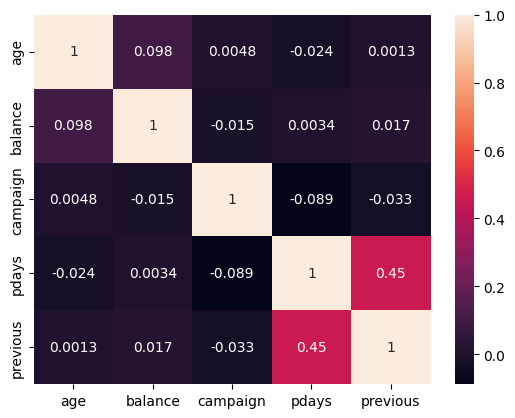

In [29]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(),annot=True)

- Stat: significant (p < 0.01)
- ML: high importance
- Target high-balance customers for premium deposit schemes